## **Suivi Par MPOUAVOULI Rayde Prosperin**
## **Projet : Comprendre et Appliquer le Machine Learning à la Finance avec Python**

##### Découvrir comment le Machnie Learning est utilisé dans la finance : prédiction des prix, classification des tendances et optimisation des stratégies d'investissement

### 2. **Préparer les données pour un modèle ML**

In [46]:
import yfinance as yf
import pandas as pd

#Charger les données Apple(AAPL)
data = yf.download("AAPL", start="2020-01-01", end="2024-12-31")
data.head()

C:\Users\Visiteur\AppData\Local\Temp\ipykernel_60856\4006882040.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("AAPL", start="2020-01-01", end="2024-12-31")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.538521,72.598899,71.292311,71.545897,135480400
2020-01-03,71.833282,72.594048,71.608677,71.765659,146322800
2020-01-06,72.405663,72.444306,70.702997,70.954173,118387200
2020-01-07,72.065163,72.671356,71.845385,72.415353,108872000
2020-01-08,73.224411,73.526303,71.768086,71.768086,132079200


In [47]:
# Supprimer le niveau Ticker
data.columns =data.columns.droplevel('Ticker')
data.head()

Price,Close,High,Low,Open,Volume
Date,,,,,
2020-01-02,72.538521,72.598899,71.292311,71.545897,135480400
2020-01-03,71.833282,72.594048,71.608677,71.765659,146322800
2020-01-06,72.405663,72.444306,70.702997,70.954173,118387200
2020-01-07,72.065163,72.671356,71.845385,72.415353,108872000
2020-01-08,73.224411,73.526303,71.768086,71.768086,132079200


In [48]:
# Valeurs manquantes
data.isnull().sum()

Price
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

In [49]:
# Les valeurs abérantes 
data.describe()

Price,Close,High,Low,Open,Volume
count,1257.000000,1257.000000,1257.000000,1257.000000,1.257000e+03
mean,151.728300,153.253332,150.026016,151.571823,9.061168e+07
std,41.896383,42.035036,41.671141,41.835806,5.324605e+07
min,54.316944,55.316762,51.470008,55.215087,2.323470e+07
25%,126.607048,127.694571,124.586260,126.080057,5.546960e+07
50%,150.366394,152.119813,148.366937,150.191808,7.629970e+07
75%,176.243683,177.947034,174.809378,176.090173,1.077601e+08
max,258.103729,259.179926,256.718662,257.276679,4.265100e+08


<Axes: >

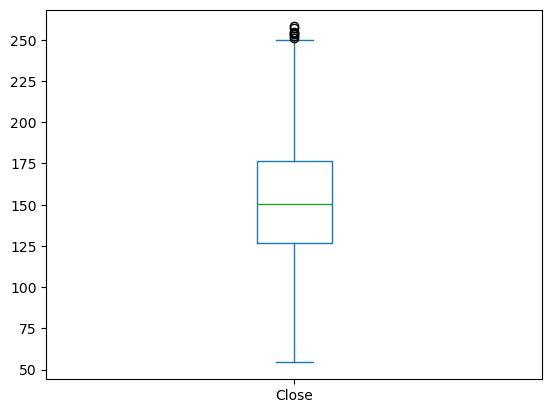

In [50]:
#Representation graphique 
data.Close.plot.box()

#### **Calcul des indicateurs techniques**

In [51]:
# Moyenne mobile 20 jours
data['SMA20'] = data['Close'].rolling(window=20).mean()
data

Price,Close,High,Low,Open,Volume,SMA20
Date,,,,,,
2020-01-02,72.538521,72.598899,71.292311,71.545897,135480400,NaN
2020-01-03,71.833282,72.594048,71.608677,71.765659,146322800,NaN
2020-01-06,72.405663,72.444306,70.702997,70.954173,118387200,NaN
2020-01-07,72.065163,72.671356,71.845385,72.415353,108872000,NaN
2020-01-08,73.224411,73.526303,71.768086,71.768086,132079200,NaN
...,...,...,...,...,...,...
2024-12-23,254.367035,254.745680,252.553466,253.868804,40858800,244.160250
2024-12-24,257.286682,257.296626,254.386957,254.586262,23234700,245.422272
2024-12-26,258.103729,259.179926,256.718662,257.276679,27237100,246.616033


In [52]:
data["diff"] =data["Close"].diff()
data['gain']= data['diff'].apply(lambda x: x if x >0 else 0)
data['loss'] =data['diff'].apply(lambda x: -x if x < 0 else 0)
data['avg_gain'] =data['gain'].rolling(window=20).mean()
data['avg_loss'] =data['loss'].rolling(window=20).mean()
data['RS'] = data['avg_gain']/data['avg_loss']
data['RSI'] = 100 - (100/(1 + data['RS']))

In [56]:
data.tail()

Price,Close,High,Low,Open,Volume,SMA20,diff,gain,loss,avg_gain,avg_loss,RS,RSI,Target
Date,,,,,,,,,,,,,,
2024-12-23,254.367035,254.745680,252.553466,253.868804,40858800,244.160250,0.777237,0.777237,0.000000,1.616264,0.350755,4.607962,82.168210,1
2024-12-24,257.286682,257.296626,254.386957,254.586262,23234700,245.422272,2.919647,2.919647,0.000000,1.612776,0.350755,4.598019,82.136539,1
2024-12-26,258.103729,259.179926,256.718662,257.276679,27237100,246.616033,0.817047,0.817047,0.000000,1.544516,0.350755,4.403410,81.493167,0
2024-12-27,254.685883,257.784897,252.164833,256.917949,42355300,247.645380,-3.417847,0.000000,3.417847,1.544516,0.515170,2.998073,74.987952,0
2024-12-30,251.307861,252.603266,249.862994,251.337754,35557500,248.386250,-3.378021,0.000000,3.378021,1.424940,0.684071,2.083031,67.564391,0


#### **Créer la variable cible (ex: hausse du prix demain)**

In [55]:

data['Target'] = (data['Close'].shift(-1) > data['Close']).astype(int)
data.dropna(inplace =True)

Price,Close,High,Low,Open,Volume,SMA20,diff,gain,loss,avg_gain,avg_loss,RS,RSI,Target
Date,,,,,,,,,,,,,,
2020-01-30,78.218903,78.272036,76.982356,77.414667,126743200,75.360955,-0.113518,0.000000,0.113518,0.560069,0.276050,2.028868,66.984361,0
2020-01-31,74.750786,77.931512,74.456139,77.508864,199588400,75.471568,-3.468117,0.000000,3.468117,0.560069,0.449456,1.246105,55.478478,0
2020-02-03,74.545494,75.712000,72.990148,73.492492,173788400,75.607178,-0.205292,0.000000,0.205292,0.560069,0.424459,1.319491,56.887086,1
2020-02-04,77.006523,77.197321,75.745823,76.151564,136616400,75.837222,2.461029,2.461029,0.000000,0.654502,0.424459,1.541968,60.660402,1
2020-02-05,77.634438,78.433846,77.030654,78.134364,118826800,76.115685,0.627914,0.627914,0.000000,0.685897,0.407434,1.683458,62.734648,1


### **3. Construire un modèle de classification pour le trading pour prédire des variables qualitatives**
###### Dans cette section, nous allons construire un modèle de classification pour prédire des signaux d’achat ou de vente à partir de données boursières.

#### **Objectif**
##### Le but est d’apprendre à une machine à classer chaque jour boursier en deux catégories :

##### 1 = Achat : le prix a de fortes chances d’augmenter demain.
##### 0 = Vente ou Ne rien faire : le prix risque de baisser ou de stagner.
##### Ce type de modèle est utilisé dans des stratégies dites discrétionnaires automatisées, où chaque prédiction devient un signal de trading.

##### Exemple
##### Nous allons utiliser des indicateurs techniques comme :

##### **La moyenne mobile (SMA)**
##### **Le RSI (Relative Strength Index)**
##### Ces indicateurs serviront de features (variables explicatives) pour notre modèle.
##### Ensuite, on utilisera un classificateur de type Random Forest (ou SVM, KNN, etc.) pour :

##### Apprendre à partir de données historiques
##### Générer un signal binaire : acheter ou non
##### Étapes à suivre :
##### Séparer les données en variables explicatives (features) et cible (target).
##### Diviser le dataset en jeu d’entraînement et jeu de test.
##### Entraîner un modèle de classification.
##### Évaluer la précision des prédictions à l’aide de métriques comme accuracy, precision, recall, f1-score.
##### Ce modèle sera plus tard intégré dans une stratégie de trading automatisée que nous pourrons simuler.

In [57]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split # Diviser la base en deux
from sklearn.metrics import classification_report, roc_curve, auc #Pour mesurer la pertinence du modèle
import matplotlib.pyplot as plt


In [59]:
# Features & target
features =['SMA20', 'RSI']
x=data[features]
y = data['Target']

In [67]:
# Split train/test
x_train, x_test, y_train, y_test= train_test_split(x, y, shuffle=False, test_size=0.2) #Ensemble des features de la base d'apprentissage (la base test represente 20% de la base totale)

In [68]:
#Modèle
clf = RandomForestClassifier(n_estimators=100, random_state=0)
clf.fit(x_train, y_train)

RandomForestClassifier(random_state=0)

In [69]:
# Prédictions
y_pred = clf.predict(x_test)
print(classification_report(y_test, y_pred)) 
#Plus la précision est élévée plus le modèle est performant)

              precision    recall  f1-score   support

           0       0.41      0.80      0.54       106
           1       0.50      0.15      0.23       142

    accuracy                           0.43       248
   macro avg       0.46      0.47      0.39       248
weighted avg       0.46      0.43      0.36       248



#### **ROC (Receiver Operating Characteristic) est une courbe qui montre la performance du modèle pour différents seuils de décision.**
##### auc(fpr, tpr) → calcule l’aire sous la courbe ROC (AUC) :

#### **AUC = 1.0 → modèle parfait**

#### **AUC = 0.5 → modèle aléatoire (aucune capacité prédictive)**

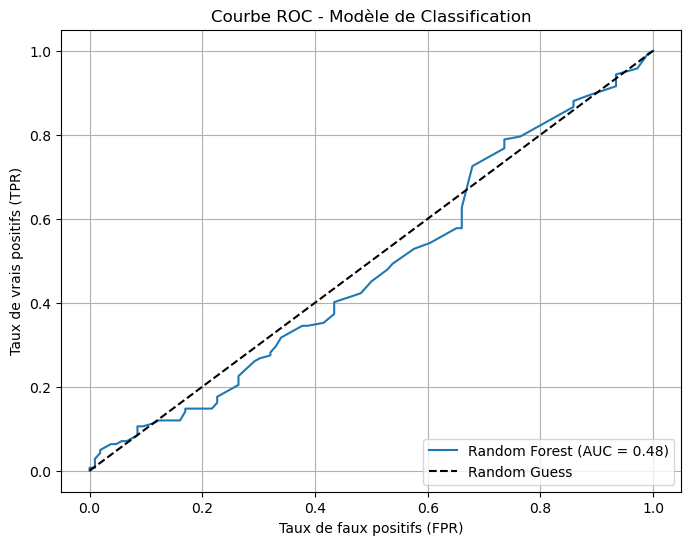

In [71]:
# Prédictions probabilistes
y_prob = clf.predict_proba(x_test)[:, 1]

# Calcul ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Affichage courbe ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Random Forest (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('Taux de faux positifs (FPR)')
plt.ylabel('Taux de vrais positifs (TPR)')
plt.title('Courbe ROC - Modèle de Classification')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

##### **AUC < 0.48 Un AUC (Area Under the Curve) inférieur à 0.5, comme AUC < 0.48, est un signal d’alerte important le modèle n'est pas important**

### **4. Construire un modèle de régression pour prévoir les prix (Variables quantitatives)**
##### Dans cette section, nous allons construire un modèle de régression pour estimer les prix futurs d'une action à partir des données historiques.

#### **Objectif**
#####  Contrairement à un modèle de classification, qui prédit une classe (par exemple "achat" ou "vente"), un modèle de régression permet de prédire une valeur numérique continue. Dans le cadre de ce projet, nous chercherons à estimer le prix de clôture du lendemain à partir des indicateurs techniques calculés aujourd’hui.

##### L’objectif est d’anticiper les variations futures du marché afin de prendre des décisions d’investissement éclairées.

#####  **Exemple de cas d’usage**
#####  Si le modèle prédit que le prix de l’action Apple sera de 145.30 dollars demain, alors qu’il est aujourd’hui à 140.00 dollars, cela peut indiquer une opportunité d’achat. Inversement, une baisse anticipée du prix peut justifier une décision de vente.

#####  **Modèles de régression possibles**
##### Voici quelques modèles fréquemment utilisés pour ce type de tâche :
##### - Régression linéaire
##### - Lasso et Ridge (régularisés)
##### - Random Forest Regressor
##### - Gradient Boosting Regressor (XGBoost, LightGBM, etc.)

##### Nous utiliserons ici le modèle Random Forest Regressor, bien adapté aux relations complexes et non linéaires dans les données financières.

##### **Étapes à suivre**
#####  1- Créer la variable cible en décalant le prix de clôture d’un jour : Close_tomorrow = Close.shift(-1)
##### 2- Sélectionner les indicateurs techniques comme variables explicatives (features)
##### 3- Diviser les données en jeu d’entraînement et de test
##### 4- Entraîner le modèle de régression
##### 5- Évaluer la qualité des prédictions à l’aide de métriques appropriées :
##### - RMSE (Root Mean Squared Error) : mesure l’erreur quadratique moyenne
##### - MAE (Mean Absolute Error) : moyenne des écarts absolus
#####  -R² (coefficient de détermination) : proportion de la variance expliquée par le modèle

#### **Remarques**
##### Un bon modèle de régression ne garantit pas une bonne stratégie de trading. Il est essentiel de :

##### - Vérifier la stabilité du modèle dans le temps
##### - Intégrer les prédictions dans une stratégie d’investissement testée sur le long terme
##### - Comparer les performances à des approches plus simples (moyenne mobile, Buy & Hold, etc.)
##### - L’intégration d’un modèle de régression dans une stratégie de trading fera l’objet de la prochaine section.

In [79]:
# Import des bibliothèques nécessaires
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score 
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd

# 1. Préparer la variable cible (prix de clôture du lendemain)
data['Close_tomorrow'] = data['Close'].shift(-1)

# 2. Supprimer les lignes avec valeurs manquantes (créées par shift)
data.dropna(inplace=True)

# 3. Définir les variables explicatives et la variable cible
# Il faut définir 'features' : par exemple les colonnes utilisées pour prédire
features = ['Open', 'High', 'Low', 'Close', 'Volume', 'SMA20', 'RSI']  # adapte selon ton dataset

X = data[features]
y = data['Close_tomorrow']

# 4. Séparer les données en train et test (sans mélanger dans le temps)
X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=False, test_size=0.2)

# 5. Créer et entraîner le modèle Random Forest
reg = RandomForestRegressor(n_estimators=100, random_state=0)
reg.fit(X_train, y_train)

# 6. Prédire les prix de clôture du test
y_pred = reg.predict(X_test)

# 7. Évaluer les performances
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

In [81]:
 ##### Calculer les métriques d’évaluation
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")  #RMSE → erreur moyenne entre les valeurs réelles et prédites
print(f"R² Score: {r2:.4f}") #R² → pourcentage de la variance expliquée par le modèle (plus proche de 1 = meilleur)

Root Mean Squared Error (RMSE): 24.1949
R² Score: 0.0260


##### RMSE = 24.19 Cela veut dire que, en moyenne, ton modèle se trompe d’environ 24 $ sur la prédiction du prix de clôture d’Apple.
##### R² = 0.026 Le coefficient de détermination (R²) indique que ton modèle n’explique que 2,6 % de la variance** du prix.
##### En clair : le modèle n’apprend pas vraiment de relation solide entre les variables explicatives et le prix de clôture futur.

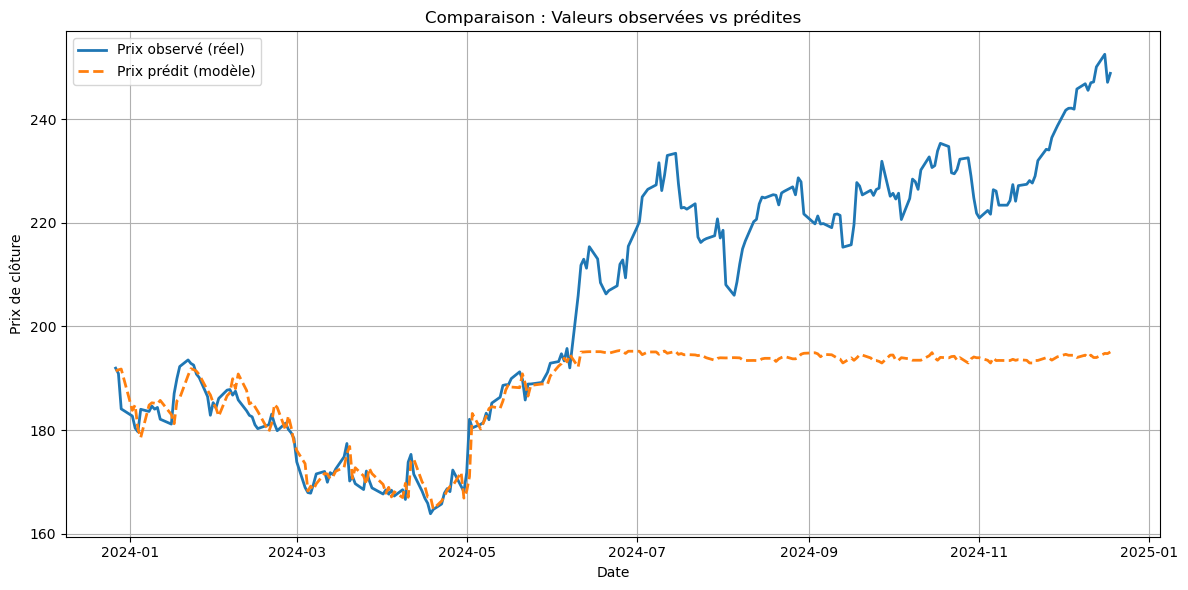

In [82]:
#Visualisation valeurs observées vs les valeurs prédites
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test.values, label="Prix observé (réel)", linewidth=2)
plt.plot(y_test.index, y_pred, label="Prix prédit (modèle)", linestyle='--', linewidth=2)
plt.title("Comparaison : Valeurs observées vs prédites")
plt.xlabel("Date")
plt.ylabel("Prix de clôture")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Les valeurs prédites sont très éloignées de la réalité

### **5. Tester les performances des modèles ML**
##### Évaluation des performances des modèles
##### Une fois les modèles entraînés (classification ou régression), il est essentiel d’évaluer leur performance à l’aide de métriques adaptées. Voici un tableau récapitulatif des principales métriques utilisées :

In [83]:
import pandas as pd

# Création du tableau sous forme de DataFrame
metriques = {
    "Métrique": [
        "Accuracy", "Precision", "Recall", "F1-score", "AUC (ROC)",
        "RMSE", "MAE", "R² (coefficient de détermination)"
    ],
    "Type de modèle": [
        "Classification", "Classification", "Classification", "Classification", "Classification",
        "Régression", "Régression", "Régression"
    ],
    "Interprétation": [
        "Proportion de prédictions correctes. Peut être trompeuse si les classes sont déséquilibrées.",
        "Parmi les prédictions positives, combien sont correctes ? Mesure la qualité des prédictions positives.",
        "Parmi les vraies valeurs positives, combien ont été correctement prédites ? Utile pour ne pas rater les cas importants.",
        "Moyenne harmonique entre précision et rappel. Bon compromis lorsque les classes sont déséquilibrées.",
        "Surface sous la courbe ROC. Mesure la capacité du modèle à distinguer les classes. 1 = parfait, 0.5 = aléatoire.",
        "Racine de l’erreur quadratique moyenne. Plus la valeur est basse, meilleure est la prédiction.",
        "Moyenne des erreurs absolues. Représente l’erreur moyenne en valeur absolue.",
        "Proportion de la variance expliquée par le modèle. 1 = parfait, 0 = aucune explication. Une valeur négative signifie que le modèle est pire que la moyenne."
    ]
}

# Conversion en DataFrame
df_metriques = pd.DataFrame(metriques)

# Affichage du tableau
df_metriques.style.set_properties(**{'text-align': 'left'}).set_table_styles([
    {'selector': 'th', 'props': [('text-align', 'left'), ('background-color', '#d3d3d3')]},
    {'selector': 'td', 'props': [('text-align', 'left')]}
])


,Métrique,Type de modèle,Interprétation
0,Accuracy,Classification,Proportion de prédictions correctes. Peut être trompeuse si les classes sont déséquilibrées.
1,Precision,Classification,"Parmi les prédictions positives, combien sont correctes ? Mesure la qualité des prédictions positives."
2,Recall,Classification,"Parmi les vraies valeurs positives, combien ont été correctement prédites ? Utile pour ne pas rater les cas importants."
3,F1-score,Classification,Moyenne harmonique entre précision et rappel. Bon compromis lorsque les classes sont déséquilibrées.
4,AUC (ROC),Classification,"Surface sous la courbe ROC. Mesure la capacité du modèle à distinguer les classes. 1 = parfait, 0.5 = aléatoire."
5,RMSE,Régression,"Racine de l’erreur quadratique moyenne. Plus la valeur est basse, meilleure est la prédiction."
6,MAE,Régression,Moyenne des erreurs absolues. Représente l’erreur moyenne en valeur absolue.
7,R² (coefficient de détermination),Régression,"Proportion de la variance expliquée par le modèle. 1 = parfait, 0 = aucune explication. Une valeur négative signifie que le modèle est pire que la moyenne."


#### **Exemple d’interprétation**
##### Pour un modèle de classification :

##### Accuracy = 0.87 : le modèle fait 87 % de bonnes prédictions
 ##### F1-score = 0.75 : bon équilibre entre faux positifs et faux négatifs
##### AUC = 0.92 : excellente capacité à distinguer les classes (achat/vente)

#### **Pour un modèle de régression** :
##### RMSE = 1.65 : le modèle se trompe en moyenne de 1.65 unités de prix
##### MAE = 1.20 : l'erreur absolue moyenne est de 1.20
##### R² = 0.81 : 81 % de la variance des prix est expliquée par le modèle
##### L’analyse de ces indicateurs permet de juger la pertinence du modèle et d’identifier les pistes d’amélioration (meilleures features, réglage des hyperparamètres, etc.).

### **6. Intégrer le modèle ML dans une stratégie de trading**
##### Jusqu’ici, nous avons entraîné des modèles de Machine Learning pour prédire des signaux (achat/vente) ou des prix futurs. Cependant, une prédiction seule n’a pas de valeur si elle n’est pas intégrée dans une stratégie concrète de prise de décision. Cette section consiste à transformer les résultats du modèle en actions exploitables sur les marchés.

#### **Objectif**
##### Utiliser les prédictions du modèle pour générer des signaux de trading automatiques, puis simuler une stratégie d’investissement basée sur ces signaux. Cela permet de tester si le modèle aurait permis de réaliser un profit, comparé à une stratégie de base comme le Buy & Hold.

#### **Principe de fonctionnement**
##### Générer les signaux : à partir des prédictions du modèle (classification), on crée une colonne "Signal" qui indique quoi faire :

#### 1 → acheter (anticipation de hausse)
#### 0 → ne rien faire ou vendre (anticipation de baisse)

#### **Calculer les rendements** :
##### Returns : les rendements quotidiens réels du marché (basés sur le prix de clôture)
##### Strategy_Returns : rendements générés par la stratégie basée sur les signaux du modèle

#### **Comparer les performances **:

##### Simuler les deux stratégies dans le temps :
##### - Buy & Hold : investir au début et ne rien faire jusqu’à la fin
##### - ML Strategy : acheter uniquement lorsque le modèle le recommande
##### Visualiser les performances cumulées dans un graphique

#### **Avantages de cette approche**
##### - Permet de valider la valeur réelle du modèle dans un contexte d’investissement
##### - Met en évidence les cas où le modèle aurait généré un gain ou une perte
##### - Sert de base à une optimisation future (filtrage des signaux, stop loss, take profit, etc.)

#### **Limites**
##### - Ce backtest ne prend pas encore en compte les frais de transaction, glissements, ou volumes disponibles, qui peuvent impacter fortement les performances réelles
##### -Il s’agit d’une simulation sur le passé : une bonne performance historique ne garantit pas des résultats futurs

##### L’intégration de ces signaux dans une stratégie de trading robuste et testée est une étape clé vers l’automatisation et l’application réelle du Machine Learning en finance.

In [93]:
# Définition des features (identiques à celles du fit)
features = ['SMA20', 'RSI']  # <-- adapte selon ton modèle

# Séparation cohérente train / test
X = data[features]
y = data['Target']  # ou ta variable de classification

X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=False, test_size=0.2)

# Entraînement
clf = RandomForestClassifier(n_estimators=100, random_state=0)
clf.fit(X_train, y_train)

# Prédiction cohérente
data_test = data.iloc[-len(y_test):].copy()
data_test['Signal'] = clf.predict(X_test)  # les features correspondent
data_test.tail()


Price,Close,High,Low,Open,Volume,SMA20,diff,gain,loss,avg_gain,avg_loss,RS,RSI,Target,Close_tomorrow,Signal
Date,,,,,,,,,,,,,,,,
2024-12-12,247.082886,247.860125,244.810937,246.016663,32777500,236.022136,1.464798,1.464798,0.000000,1.402523,0.264561,5.301313,84.130291,1,247.252274,0
2024-12-13,247.252274,248.408159,245.368960,246.943373,33155300,237.014114,0.169388,0.169388,0.000000,1.256540,0.264561,4.749520,82.607243,1,250.151978,0
2024-12-16,250.151978,250.490786,246.773970,247.112779,51694800,238.311509,2.899704,2.899704,0.000000,1.401525,0.104131,13.459307,93.084039,1,252.583344,0
2024-12-17,252.583344,252.932112,248.896435,249.195377,51356400,239.580006,2.431366,2.431366,0.000000,1.372628,0.104131,13.181799,92.948708,0,247.172562,0
2024-12-18,247.172562,253.380520,246.863661,251.268024,56774100,240.565010,-5.410782,0.000000,5.410782,1.359673,0.374670,3.628992,78.397027,1,248.906403,0


In [94]:
# Étape 2 : Calculer les rendements du marché
# Rendement quotidien : variation relative du prix de clôture
data_test['Returns'] = data_test['Close'].pct_change()

# Rendement de la stratégie basée sur les signaux
# On applique le signal de la veille au rendement du jour
data_test['Strategy_Returns'] = data_test['Returns'] * data_test['Signal'].shift(1)

In [95]:
# Étape 3 : Performance cumulée
data_test['Cumulative_Market'] = (1 + data_test['Returns']).cumprod()
data_test['Cumulative_Strategy'] = (1 + data_test['Strategy_Returns']).cumprod()

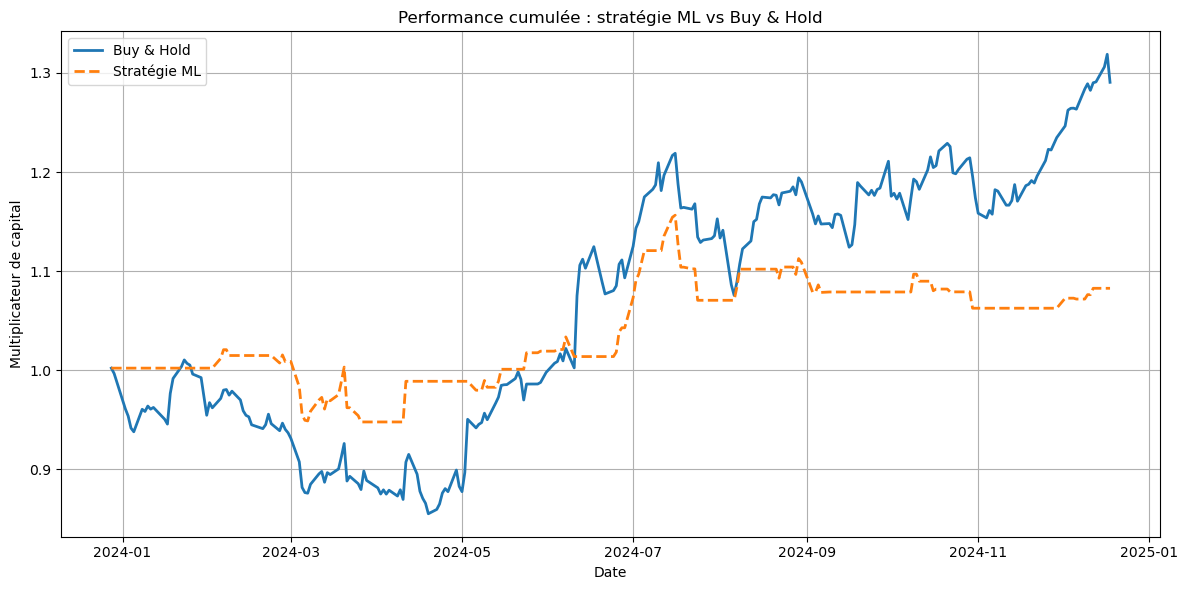

In [96]:
# Étape 4 : Visualisation
plt.figure(figsize=(12, 6))
plt.plot(data_test.index, data_test['Cumulative_Market'], label='Buy & Hold', linewidth=2)
plt.plot(data_test.index, data_test['Cumulative_Strategy'], label='Stratégie ML', linewidth=2, linestyle='--')
plt.title('Performance cumulée : stratégie ML vs Buy & Hold')
plt.xlabel('Date')
plt.ylabel('Multiplicateur de capital')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()